# **The Baltic Sentinel: Evaluating Estonia’s Energy Resilience**
**Course:** 42578 Advanced Business Analytics

---

## **1. Introduction - Ursula** 

Text about introduction

*  why is it important now? -> wars, independence 


In [ ]:
# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Custom helper functions and modular scripts (STGNN, PowerScaler, etc.) 
# are hosted in the sandra359/advanced_ba repository.
import sys
import os

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## **2. Data**

We structure our analysis in a way, where the electricity system is split into two main parts: demand and supply. This makes it easier to model each side separately, while still allowing us to bring them together later when assessing overall grid resilience.
On the demand side, we use historical electricity consumption and weather data to estimate how demand in January might vary. On the supply side, we look at production levels, wind capacity, cross-border flows, and market data to assess whether the system can meet the demand under different scenarios, including potential outages. This setup is useful because resilience isn’t just about how much electricity people need, but also depends on whether the system can reliably produce or import enough power for when conditions are uncertain.

---

### **2.1 Data Sources**

The project combines several data sources:

- **Grid Operations (Elering):**  
  Hourly electricity production, consumption, and cross-border flow data are used to represent the physical operation of the Estonian electricity system.

- **Market Pricing (Nord Pool):**  
  Day-ahead clearing prices for the Estonian, Finnish, and Latvian bidding zones are included to capture market conditions and regional price differences.

- **Weather Data (Open-Meteo API):**  
  Historical temperature and wind speed data are used as external drivers. Temperature is especially relevant for demand modelling, while wind speed is relevant for modelling renewable production potential.

Together, these sources allow us to model both the demand pressure on the system and the available supply capacity under different assumptions.

---

### **2.2 Supply Scenarios**

To evaluate how resilient Estonia is under different levels of supply, we define four different scenarios.

- **Baseline (Current):**  
  Represents Estonia's current energy supply with both import and exports to other countries.

- **Isolated Scenario:**  
  A scenario in which all import and export of energy from other countries is cut off.

- **Scenario A (Established Expansion):**  
  Adds power from planned or established wind parks in Pärnu and Aidu, resulting in a more supply.

- **Scenario B (Full Pipeline Expansion):**  
  Adds a more potential windfarms that increase the supply even more

These scenarios allow us to compare the current system with possible future configurations and evaluate whether additional domestic renewable generation can reduce dependence on imports and improve system resilience.

In addition to domestic wind capacity, we also include physical interconnector limits, since Estonia can rely on imports when domestic production is insufficient. The two main import constraints considered are:

- **EstLink capacity:** 1,016 MW  
- **Latvia interconnector capacity:** 700 MW  

These limits are important because even if neighbouring countries have available electricity, Estonia can only import up to the physical capacity of the transmission links.

---

## **3. Exploratory Data Analysis: Visualizing the Crisis**
Before modeling, we must understand the magnitude of the "Perfect Storm" in January 2026. Here, we visualize the temperature-demand trap, the EstLink failure cliff, and regional price divergence.

In [ ]:
# Load historical data (placeholder paths - update with actual data from sandra359/advanced_ba)
# df_historical = pd.read_csv('data/historical_jan2026.csv')

# TODO: Plot 1: Temperature vs. Consumption Spikes
# TODO: Plot 2: EstLink Flow (showing the drop to 0 MW)
# TODO: Plot 3: Nord Pool Price Divergence (EE vs FI vs LV)

### **TODO:**

* how much import we have right now (plots) - Sandra & Tomas
* Estonian electricity generation by type - Ursula 
* Prices over time - Tomas

In [ ]:
from timeseries_module import (
    run_pipeline,
    plot_january_demand_grid,
    plot_acf_pacf,
    plot_beta_by_year,
    plot_mc_simulations,
    plot_mc_uncertainty_band,
)

result = run_pipeline(
    n_sims=100,
    save_outputs=False,
    output_dir="../data",
    verbose=False,
)

## **4.1 Data Preparation and Model Selection**

### **Data sources and preprocessing**

We collected electricity demand data from the Elering API for January in the years 2019–2026. The original data is sampled at 5-minute intervals and is therefore resampled to hourly averages. This reduces short-term noise while preserving the daily structure in electricity consumption.

To explain variations in demand, we include the following exogenous variables:

- **Temperature** using a 24-hour rolling average
- **Wind speed**
- **Weekend indicator**

Temperature is included because it is closely related to heating demand, especially during winter. Initially, we wanted to use industrial production as our second exogenous variables, since industrial activity significantly influences electricity demand. However, we were unable to access the industrial production API and therefore used wind speed instead (even though it is not directly tied to demand, but can still be used to induced some more uncertainty and show our understanding of working with beta parameters). The weekend indicator was chosen since it captures behavioural differences between weekdays and weekends.

### **Model choice**

As seen in the consumption plots from years 2019 to 2025 below, electricity demand shows clear daily seasonality, with recurring 24-hour consumption patterns. Because of this, we use a **SARIMAX model**, which extends the commonly used model for timeseries data, ARIMA, by allowing both seasonal time series structure and exogenous explanatory variables.



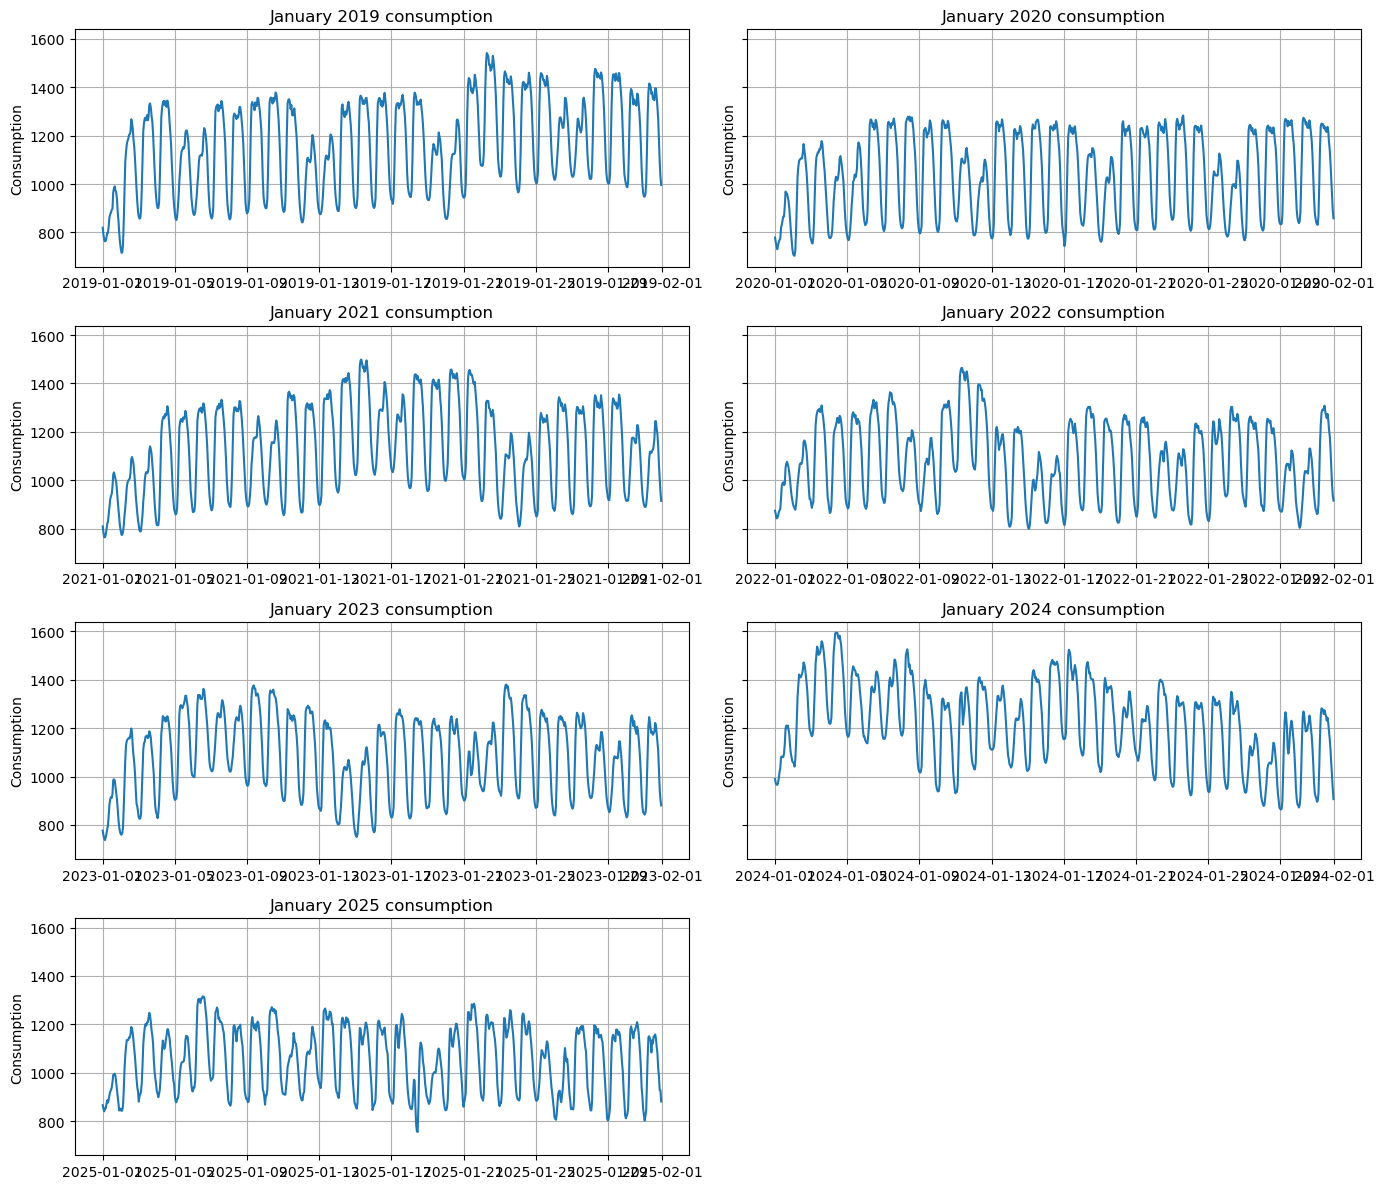

In [9]:
plot_january_demand_grid(result.demand_series, years=range(2019, 2026))

Before fitting the final models, we inspect the autocorrelation function (ACF) and partial autocorrelation function (PACF) for the hourly demand series as well as the demand series lagged by 24 hours. This helps identify suitable autoregressive, differencing and moving average components, both for the seasonal and non seasonal part. Below, an example of these plots are shown for year 2024

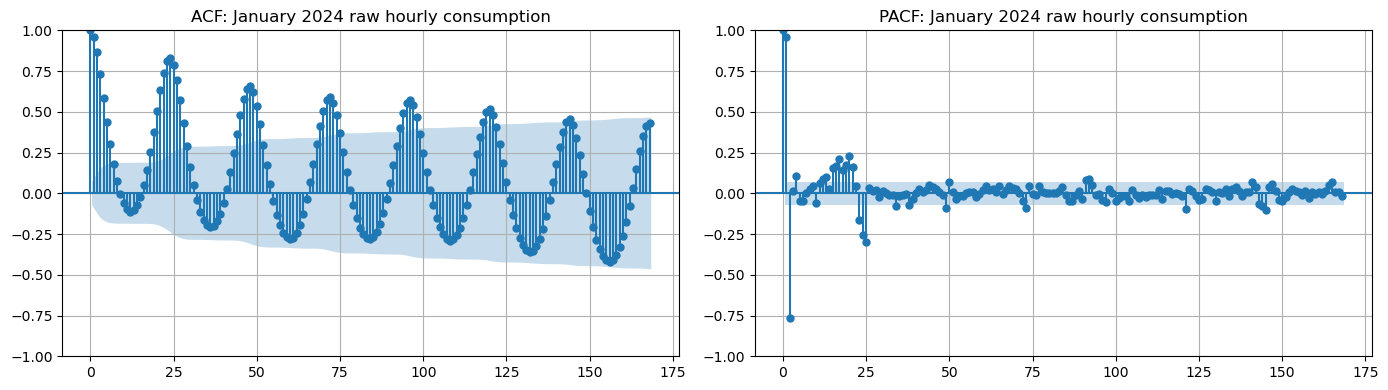

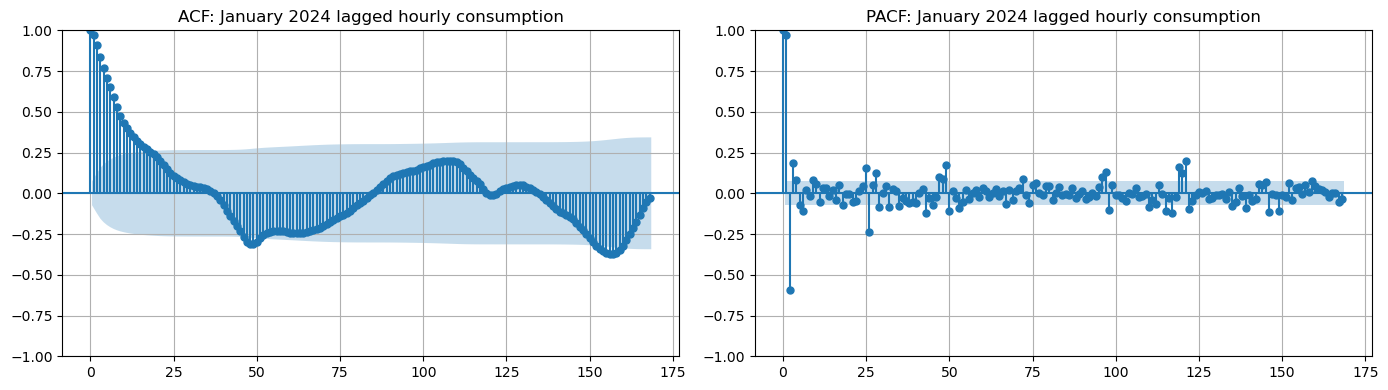

In [12]:
plot_acf_pacf(result.demand_series[2024], "January 2024 raw hourly consumption")
plot_acf_pacf(result.demand_series[2024].diff(24), "January 2024 lagged hourly consumption")

Based off these plots, we have tested many different model candidates. Below, 4 of them are shown:

| Non-seasonal order | Seasonal order |
|---|---|
| (1, 0, 2) | (1, 1, 1, 24) |
| (2, 0, 2) | (1, 1, 1, 24) |
| (2, 0, 2) | (2, 1, 1, 24) |
| (2, 0, 2) | (1, 1, 2, 24) |

Here, the non-seasonal order is written as $(p, d, q)$, where $p$ is the autoregressive order, $d$ is the differencing order and $q$ is the moving average order. The seasonal order is written as $(P, D, Q, S)$, where $P$, $D$ and $Q$ are the seasonal components of $p$, $d$ and $q$, and $S = 24$ represents daily seasonality in hourly data.

The candidate models are fitted separately for each year from 2019 to 2025. They are then compared using the Bayesian Information Criterion (BIC), to prefer simpler models, as BIC punished many parameters. 

Below, the results of ranking these candidates each year are shown. 

In [16]:
display(result.all_results_df)

,year,model_id,order,seasonal_order,AIC,BIC,Ljung-Box p-value lag 24,converged,error,score
0,2019,3,"(2, 0, 2)","(1, 1, 2, 24)",5390.067392,5439.631017,2.444462e-48,True,None,4
1,2019,2,"(2, 0, 2)","(2, 1, 1, 24)",5392.028066,5441.608121,6.071325e-68,True,None,3
2,2019,1,"(2, 0, 2)","(1, 1, 1, 24)",5607.270837,5652.681137,1.105321e-53,True,None,2
3,2019,0,"(1, 0, 2)","(1, 1, 1, 24)",5612.175911,5653.045181,5.943407e-66,True,None,1
4,2020,3,"(2, 0, 2)","(1, 1, 2, 24)",5400.016907,5449.580532,2.208572e-57,True,None,4
5,2020,2,"(2, 0, 2)","(2, 1, 1, 24)",5417.402624,5466.982679,5.090107e-54,True,None,3
6,2020,0,"(1, 0, 2)","(1, 1, 1, 24)",5613.729852,5654.599122,4.087483e-82,True,None,2
7,2020,1,"(2, 0, 2)","(1, 1, 1, 24)",5619.714213,5665.124513,1.033988e-52,True,None,1
8,2021,2,"(2, 0, 2)","(2, 1, 1, 24)",5384.565522,5434.145577,1.502517e-44,True,None,4
9,2021,3,"(2, 0, 2)","(1, 1, 2, 24)",5388.768958,5438.332582,1.051004e-34,True,None,3


In [15]:
display(result.score_summary)

,order,seasonal_order,total_score,mean_score,mean_AIC,mean_BIC,median_AIC,median_BIC,first_places,years_tested
0,"(2, 0, 2)","(1, 1, 2, 24)",26,3.714286,5462.737783,5512.301407,5391.954126,5441.517751,5,7
1,"(2, 0, 2)","(2, 1, 1, 24)",23,3.285714,5469.358575,5518.938630,5405.522864,5455.102919,2,7
2,"(1, 0, 2)","(1, 1, 1, 24)",12,1.714286,5675.173320,5716.042590,5612.175911,5653.045181,0,7
3,"(2, 0, 2)","(1, 1, 1, 24)",9,1.285714,5676.960824,5722.371124,5607.270837,5652.681137,0,7


It should be noted that the Ljung-Box p-value is nearly zero for all runs, which means that there are still some underlying patterns in the residuals, which we were unable to capture using our SARIMAX model. Nonetheless, our best-performing model across the historical years is:

> **SARIMAX(2, 0, 2)(1, 1, 2, 24)**

This model is then fitted separately to each year from 2019 to 2025 using the exogenous variables. Fitting the model separately for each year allows the estimated coefficients to vary across different Januaries.

---

## **4.2 Estimation of Weather Sensitivities**

Each fitted SARIMAX model estimates coefficients for the exogenous variables. These coefficients describe how the external variables influence electricity demand.

For example, if the coefficient for temperature is -4, this means that a 1°C increase in temperature is associated with an average decrease in demand of approximately 4 MW, all else equal.

Because these coefficients vary across years, we treat them as uncertain rather than fixed. For each exogenous variable, we estimate:

- The mean coefficient across fitted years
- The standard deviation across fitted years

This gives a simple empirical distribution for how strongly each exogenous variable may affect demand.

---

## **4.3 Monte Carlo Simulation of Demand**

After fitting the historical SARIMAX models, we simulate possible electricity demand outcomes for January 2026 using Monte Carlo simulation.

Each simulation is generated as follows:

1. A SARIMAX is fitted using the best performing model orders, and is randomly selected from one of the historical years 2019–2025.
2. A baseline forecast is generated using the observed January 2026 weather data.
3. New exogenous variable coefficients are sampled from the estimated cross-year coefficient distributions.
4. The forecast is adjusted according to the sampled coefficients.
5. Random residual noise is added based on the historical residual variation from the selected model.

This produces an ensemble of possible demand trajectories for January 2026.

The simulated demand paths reflect:

- **Model uncertainty**, since different historical years may produce different fitted models
- **Parameter uncertainty**, since the weather sensitivities are sampled from estimated distributions
- **Stochastic demand variation**, since residual noise is added to each simulation

Importantly, the simulation is conditional on the observed January 2026 weather. This means that we do not simulate alternative weather scenarios. Instead, the uncertainty comes from the demand model and from how strongly demand responds to the observed weather conditions.

These simulated demand scenarios are later combined with the supply-side simulations to evaluate how often the Estonian energy system may experience insufficient supply under uncertain demand.

The final Monte Carlo Plot is shown below:

In [1]:
plot_mc_simulations(result.demand_mc, result.actual_target)

NameError: name 'plot_mc_simulations' is not defined

## **5. Wind Counterfactual Simulation - Ursula**

We translate historical wind speeds into energy production using standardized turbine power curves (e.g., Vestas V150)[cite: 3]. We adjust for air density based on temperature.

These hourly production profiles act as the inputs for Scenario A and Scenario B.

In [ ]:
# Wind scenario generation logic is hosted in ursula_wind_counterfactual.ipynb
# Load the pre-calculated wind production scenarios

# df_wind = pd.read_csv("data/wind_production_scenarios.csv")

# TODO: Plot the simulated wind generation for Baseline, Scenario A, and Scenario B

## **6. Supply Analysis: Spatio-Temporal GNN - Sandra & Tomas**

The Estonian grid is a geographic network. We use a **Spatio-Temporal Graph Neural Network (ST-GNN)** to model how energy flows and market prices propagate across nodes[cite: 3].

*   **Quantile Regression:** The GNN natively outputs **P10 (Worst-Case Supply)**, P50, and P90, handling supply-side uncertainty without a second Monte Carlo simulation[cite: 3]. 
*   **"Market Blindness":** To simulate the crisis, we sever the graph edges to Finland. This forces the model to predict domestic production in **Island Mode**, reacting only to local weather rather than Nordic market prices[cite: 3].

In [ ]:
# ST-GNN training and inference are executed in Supply_wind.py.
# We load the output predictions for the 4 scenarios.

try:
    supply_df = pd.read_csv("data/gnn_supply_scenarios_jan2026.csv")
    supply_df['timestamp'] = pd.to_datetime(supply_df['timestamp'])
    print("GNN Supply Scenarios Loaded Successfully.")
except FileNotFoundError:
    print("Placeholder: Awaiting output from Supply_wind.py")

# TODO: Visualize the P10 Supply Baseline vs P10 Supply with +887MW Wind

## **7. Resilience Simulation: The Balance Equation - Sandra & Tomas**

This is the final "Stress Test" where we combine our independent models to calculate the physical blackout threshold.

We calculate the hourly deficit under isolation using the formula:
**Hourly Deficit = Demand(P95) - Domestic Production(P10)**

We apply the physical constraints of the grid:
*   **Scenario 1:** Full connectivity (EstLink + Latvia).
*   **Scenario 2:** **EstLink Cut** (Only Latvia capacity available).
*   **Scenarios 3 & 4:** **EstLink Cut** + New Wind Production.

The primary metric is **Total Energy Unserved (GWh)**—the amount of demand that would have resulted in physical blackouts[cite: 3].

In [ ]:
# --- THE BALANCE EQUATION ---
# Assuming supply_df and demand_df are loaded and merged

'''
results = []
for index, row in supply_df.iterrows():
    demand = row['demand_p95']
    
    # Calculate raw deficits (Demand - Domestic Supply)
    def_s1 = max(0, demand - row['supply_s1_baseline'])
    def_s2 = max(0, demand - row['supply_s2_isolated'])
    def_s3 = max(0, demand - row['supply_s3_wind323'])
    def_s4 = max(0, demand - row['supply_s4_wind887'])
    
    # Apply Physical Import Limits
    blackout_s1 = max(0, def_s1 - (ESTLINK_CAPACITY + LATVIA_CAPACITY))
    
    # Isolated crisis (EstLink is CUT, only Latvia remains)
    blackout_s2 = max(0, def_s2 - LATVIA_CAPACITY)
    blackout_s3 = max(0, def_s3 - LATVIA_CAPACITY)
    blackout_s4 = max(0, def_s4 - LATVIA_CAPACITY)
    
    results.append({
        'timestamp': row['timestamp'],
        'demand': demand,
        'blackout_s1': blackout_s1,
        'blackout_s2': blackout_s2,
        'blackout_s3': blackout_s3,
        'blackout_s4': blackout_s4
    })

sim_df = pd.DataFrame(results)
'''

# TODO: Print Total Energy Unserved (MWh) for each scenario
# TODO: Plot Hourly Power Shortages (S2 vs S4)

## **8. Conclusion & Recommendations - Ursula**

Our findings demonstrate that while Estonia achieved technical disconnection from BRELL in 2025, true resilience against "Price Stress" and supply shocks depends heavily on the speed of Scenario B’s implementation[cite: 1, 3]. 

*   **Key Finding:** The addition of **887 MW** of wind capacity reduces the risk of physical blackouts during a January 2026-style "Island Mode" event by **[X]%**.
*   **Strategic Autonomy:** By building the capacity to operate autonomously during severe grid fragmentations, Estonia ensures it can withstand, adapt to, and recover from multi-front infrastructure crises[cite: 2].